In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('spam.csv')
df.head()

,v1,v2,col1,col2,col3
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [46]:
df.isnull().sum()

v1         0
v2         0
col1    5522
col2    5560
col3    5566
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(403)

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df.shape

(5169, 5)

In [50]:
df = df.drop(columns=['col1', 'col2', 'col3'])

In [51]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
df = df.rename(columns={'v1': 'target', 'v2': 'text'})

In [53]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [54]:
df['characters'] = df['text'].apply(lambda x: len(x))

In [55]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [56]:
df['words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [57]:
df.head()

,target,text,characters,words,sentence
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [58]:
df = df.drop(columns=['text'])

In [59]:
df.head()

,target,characters,words,sentence
0,ham,111,24,2
1,ham,29,8,2
2,spam,155,37,2
3,ham,49,13,1
4,ham,61,15,1


In [60]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()

In [61]:
df['target'] = lb.fit_transform(df['target'])

In [62]:
df.head()

,target,characters,words,sentence
0,0,111,24,2
1,0,29,8,2
2,1,155,37,2
3,0,49,13,1
4,0,61,15,1


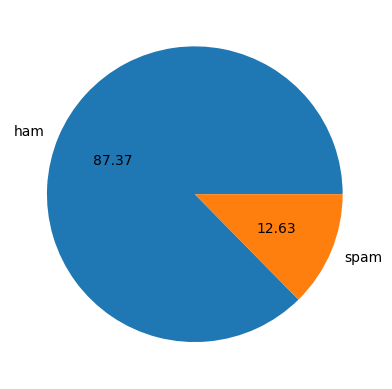

In [63]:
counts = df['target'].value_counts()
plt.pie(counts, labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

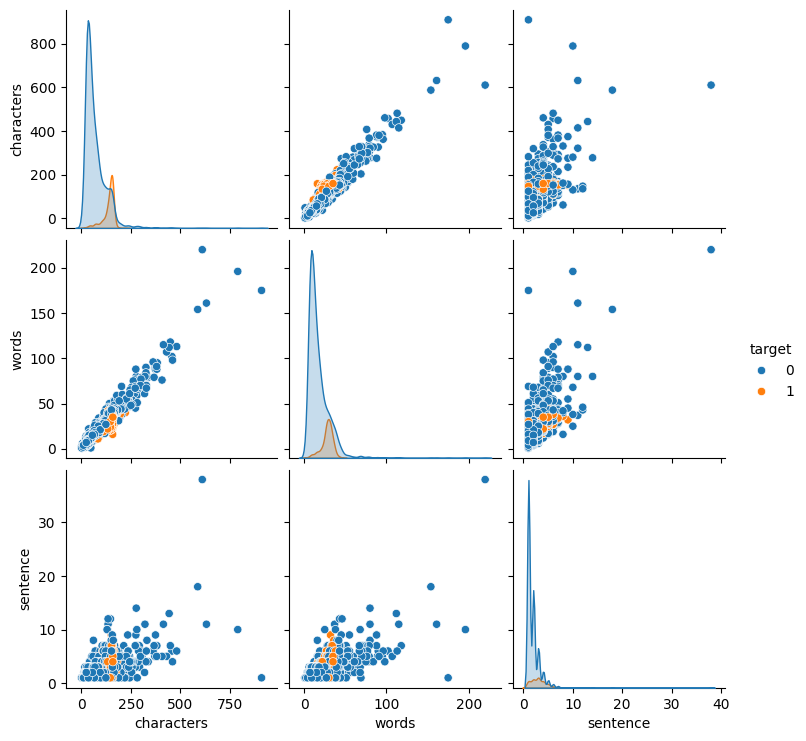

In [64]:
import seaborn as sns
sns.pairplot(df, hue='target')

In [65]:
df[['characters', 'words', 'sentence']].describe()

,characters,words,sentence
count,5169.000000,5169.000000,5169.000000
mean,78.924163,18.456761,1.966531
std,58.175349,13.325633,1.449833
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [66]:
#ham
df[df['target'] == 0][['characters', 'words', 'sentence']].describe()

,characters,words,sentence
count,4516.000000,4516.000000,4516.000000
mean,70.457263,17.123782,1.820195
std,56.357463,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [67]:
#spam
df[df['target'] == 1][['characters', 'words', 'sentence']].describe()

,characters,words,sentence
count,653.000000,653.000000,653.000000
mean,137.479326,27.675345,2.978560
std,30.014336,7.011513,1.493185
min,13.000000,2.000000,1.000000
25%,131.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


<Axes: xlabel='characters', ylabel='Count'>

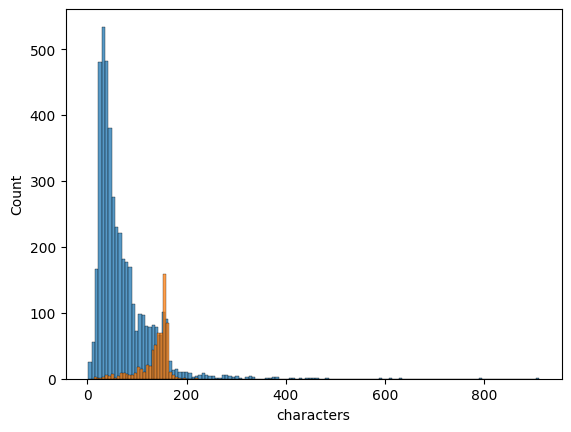

In [68]:
sns.histplot(df[df['target'] == 0]['characters'])
sns.histplot(df[df['target'] == 1]['characters'])

<Axes: xlabel='words', ylabel='Count'>

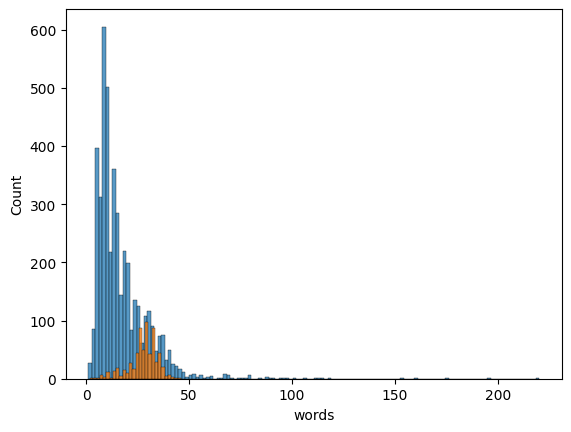

In [69]:
sns.histplot(df[df['target'] == 0]['words'])
sns.histplot(df[df['target'] == 1]['words'])

<Axes: xlabel='sentence', ylabel='Count'>

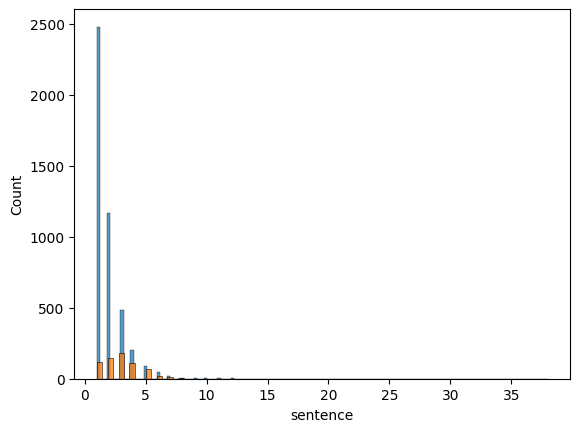

In [70]:
sns.histplot(df[df['target'] == 0]['sentence'])
sns.histplot(df[df['target'] == 1]['sentence'])

<Axes: >

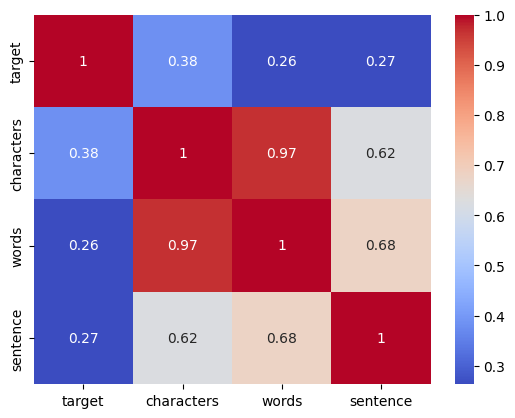

In [ ]:
# sns.heatmap(df.corr(), annot = True, cmap='coolwarm')

In [72]:
df['text'] = pd.read_csv('spam.csv', usecols=['v2'])
df.head()

,target,characters,words,sentence,text
0,0,111,24,2,"Go until jurong point, crazy.. Available only ..."
1,0,29,8,2,Ok lar... Joking wif u oni...
2,1,155,37,2,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,49,13,1,U dun say so early hor... U c already then say...
4,0,61,15,1,"Nah I don't think he goes to usf, he lives aro..."


In [81]:
import string
# string.punctuation
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
# stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [83]:
transform_text("Hey theer Panaj")

'hey theer panaj'

In [ ]:
def transform_text(text):
    #lower
    text = text.lower()
    for i in text:
        #special character 
        if i.isalnum():
            if i not in stopwords.words('english') and i not in string.punctuation()

    return text